In [116]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.preprocessing import (
    StandardScaler, 
    RobustScaler,
    PowerTransformer,
    QuantileTransformer,
    KBinsDiscretizer)
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score
from sklearn.linear_model import (
    RidgeCV, 
    Lasso, 
    LassoCV, 
    HuberRegressor, 
    LogisticRegressionCV
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_score
import shap

In [2]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy.stats import ttest_ind
# from sklearn.preprocessing import (
#     StandardScaler, 
#     RobustScaler, 
#     PowerTransformer, 
#     KBinsDiscretizer, 
#     QuantileTransformer
# )
# from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# from sklearn.metrics import r2_score
# from sklearn.feature_selection import mutual_info_regression
# from sklearn.linear_model import (
#     RidgeCV, 
#     Lasso, 
#     LassoCV, 
#     HuberRegressor, 
#     LogisticRegressionCV
# )
# from sklearn.svm import SVR
# from sklearn.neighbors import KNeighborsRegressor

In [3]:
df = pd.read_csv("stock_6_train.csv")
test_df = pd.read_csv("stock_6_test.csv")

In [4]:
df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,target
0,-0.570944,0.813764,1.068472,0.232878,0.234401,0.270343,0.471025,-0.760052,146.787077
1,-0.205162,-2.003522,1.604254,-0.457699,0.107880,1.309551,0.071674,-0.375889,196.708960
2,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,0.173653,-0.798076,125.201647
3,-0.189244,0.328662,0.361922,1.320662,-0.342786,-1.476858,1.357183,-0.146051,122.023737
4,-0.878152,-0.334123,0.915903,-1.326393,0.030631,-0.484169,-1.094665,-1.434372,195.946833
...,...,...,...,...,...,...,...,...,...
114,-0.707265,0.968998,-0.361833,-0.489750,0.908601,0.031086,-0.171234,-0.451510,177.044909
115,-0.594150,-1.446058,0.072130,-0.529493,0.232676,0.021852,-1.258604,0.264255,199.701818
116,0.777767,0.807008,-1.619872,-2.247269,1.001745,1.187725,-0.535677,0.079271,235.489057
117,-1.993060,-1.296472,-1.482185,-2.333616,-0.678264,0.749434,-2.684137,-2.473157,356.521140


Only 119 rows on this round.

In [5]:
df.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,target
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,-0.155919,0.018287,0.103290,-0.020963,-0.010924,-0.091031,0.004951,-0.173031,172.239048
std,0.957837,0.976865,1.056809,0.978773,1.000320,1.092289,1.106233,1.190063,54.923302
min,-2.964529,-2.063238,-2.394260,-2.930594,-2.409922,-3.648413,-2.684137,-3.069494,80.000000
25%,-0.848291,-0.693576,-0.501371,-0.616294,-0.546736,-0.866644,-0.722181,-0.942702,140.497456
50%,-0.152523,0.063002,0.090585,-0.049926,0.030631,-0.048718,0.053079,-0.146051,164.750020
75%,0.471337,0.650478,0.831898,0.585842,0.687588,0.655075,0.678239,0.697464,190.676204
max,2.905067,2.093168,2.517474,2.913862,2.382602,2.242920,2.414772,2.536973,400.000000


features normally distributed

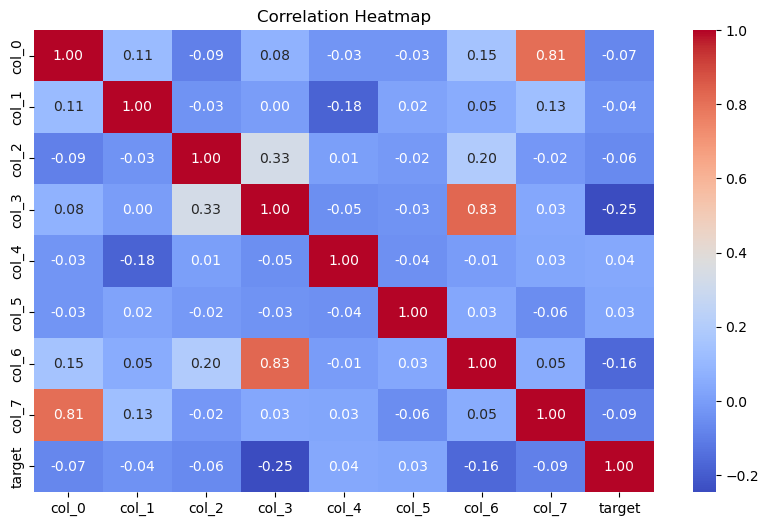

In [6]:
corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Features are all correlated in some way, allowing opportunities for feature engineering.

**col_0** and **col_7** are highly correlated

**col_3** and **col_6** are highly correlated

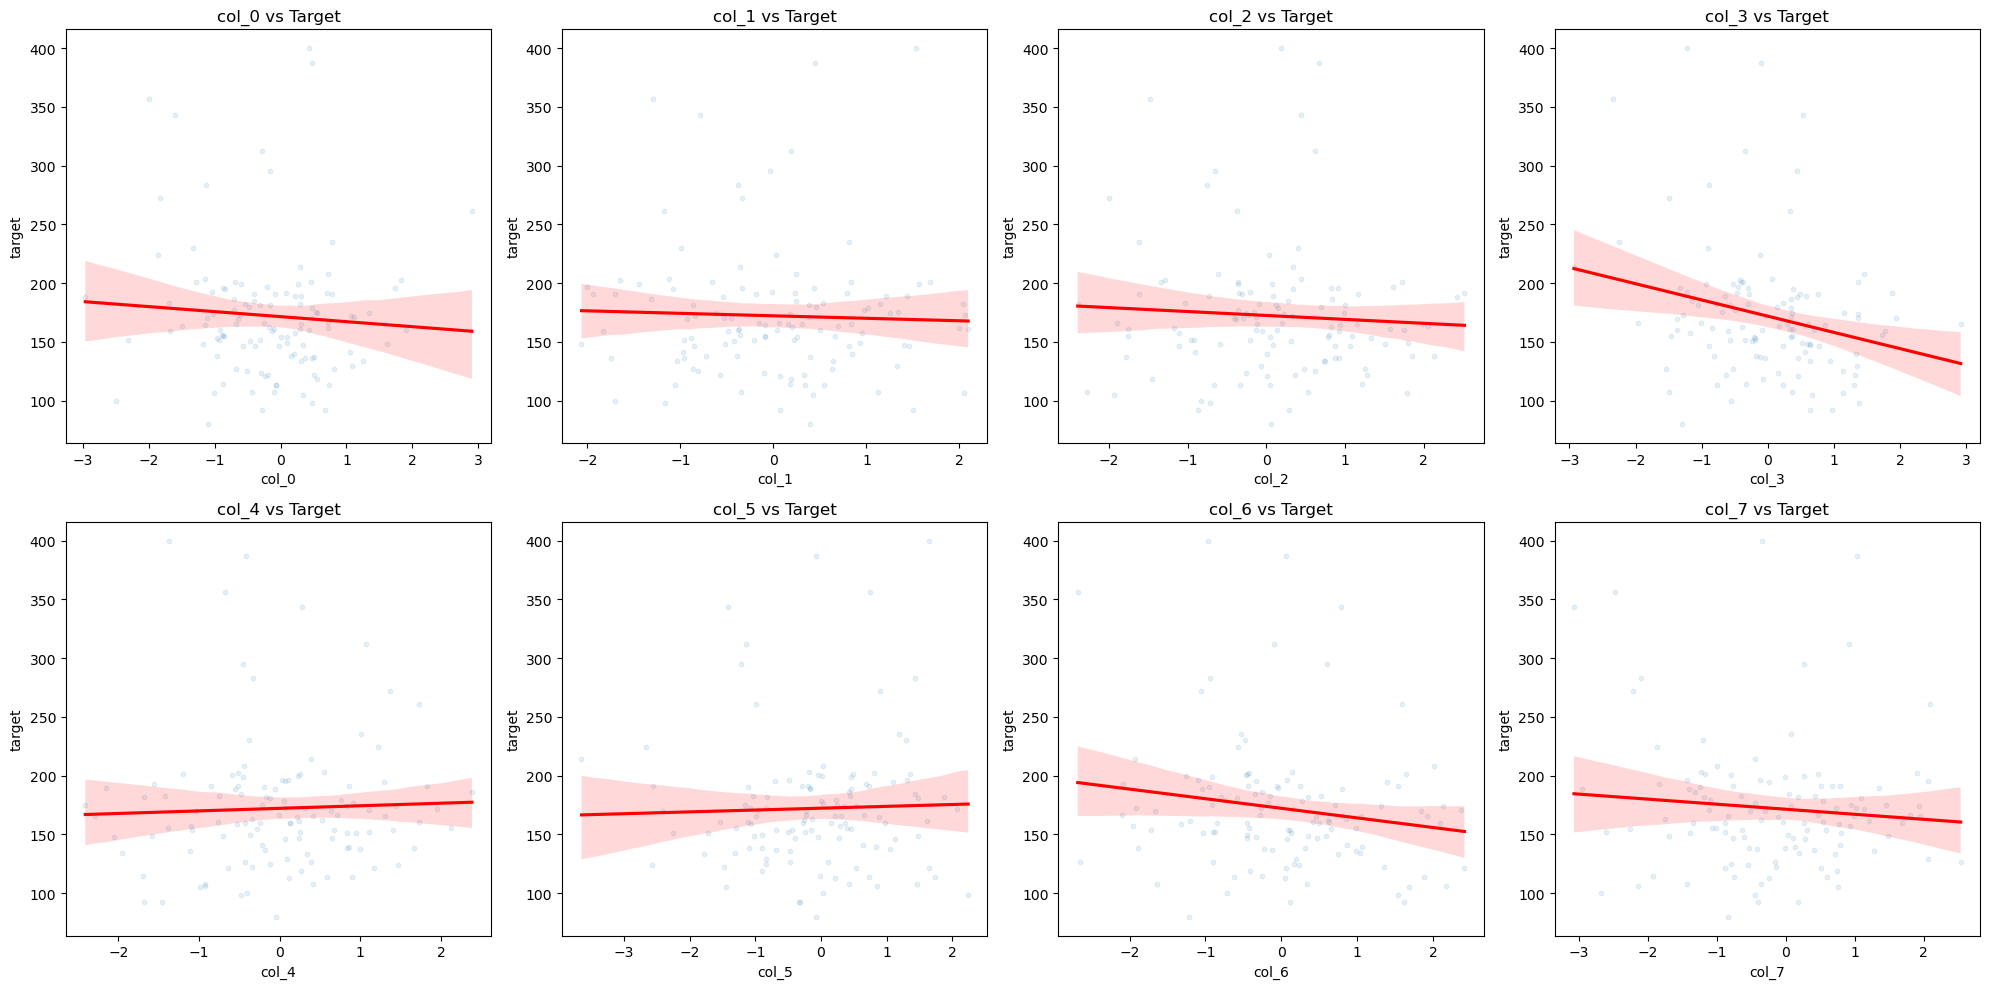

In [7]:
features = [col for col in df.columns if col.startswith('col_')]

# Create a grid: 2 rows by 4 columns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    if i >= len(axes):
        break
        
    sns.regplot(x=df[col], y=df['target'], ax=axes[i], 
                scatter_kws={'alpha':0.1, 's':10}, 
                line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

Data has a large variance for each column and there are not many data points (only 119). With not much data, is likely that a ridge/lasso regression or SVM with linear boundaries may be the best model types. Can also use a random forest with shallow trees or k nearest neighbours.

with not much data, it is also good practise to have a few key features. 50 features for only 200 data points is not sensible.

In [8]:
def feature_analysis(col, n_bins=4):
    df[f'{col}_cut'] = pd.qcut(df[col], n_bins)
    display(df.groupby([f"{col}_cut"], as_index=False, observed=True)['target'].mean())

    temp_df = df.groupby(f"{col}_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

    temp_df['noise_ratio'] = temp_df['std'] / temp_df['mean']
    display(temp_df)

    plt.figure(figsize=(12, 6))    
    ax = sns.barplot(
        data=df, 
        x=f'{col}_cut', 
        y='target', 
        palette='RdBu_r', 
        hue=f'{col}_cut',
        legend=False,
        errorbar=('ci', 95) # Adds 95% confidence intervals
    )
    
    global_mean = df['target'].mean()
    plt.axhline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Avg ({global_mean:.3f})')
    
    plt.title(f'Target Distribution by {col} Quantiles ({n_bins} Bins)', fontsize=14)
    plt.xlabel(f'{col} Quantile Ranges')
    plt.ylabel('Mean Target')
    plt.xticks(rotation=30)
    plt.legend()
    plt.show()

In [9]:
def find_best_feature_mega(df, col_name, target_name):
    X_raw = df[[col_name]].copy()
    y = df[target_name]
    temp_df = pd.DataFrame(index=df.index)
    
    # 1. Identity & Magnitude
    temp_df['original'] = X_raw[col_name]
    temp_df['abs_val'] = X_raw[col_name].abs()
    
    # 2. Polynomials
    temp_df['squared'] = X_raw[col_name]**2
    temp_df['cubed'] = X_raw[col_name]**3
    
    # 3. Handling Negatives for Logs/Roots (Shifted)
    shift = abs(X_raw[col_name].min()) + 1
    X_pos = X_raw[col_name] + shift
    
    temp_df['log_shifted'] = np.log(X_pos)
    temp_df['sqrt_shifted'] = np.sqrt(X_pos)
    temp_df['reciprocal_shifted'] = 1 / X_pos
    
    # 4. Distributional Warps (Yeo-Johnson handles negatives natively)
    yj = PowerTransformer(method='yeo-johnson')
    temp_df['yeo_johnson'] = yj.fit_transform(X_raw)
    
    # Quantile Transform (Forces Gaussian/Normal distribution)
    qt = QuantileTransformer(output_distribution='normal', n_quantiles=len(df)//2)
    temp_df['quantile_normal'] = qt.fit_transform(X_raw)
    
    # 5. Binary & Discrete
    temp_df['is_positive'] = (X_raw[col_name] > 0).astype(int)
    
    kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
    temp_df['binned_4'] = kbd.fit_transform(X_raw)

    # 6. Periodic (Assuming col might be cyclic, like -pi to pi or 0-24)
    temp_df['sin_transform'] = np.sin(X_raw[col_name])
    temp_df['cos_transform'] = np.cos(X_raw[col_name])
    
    # --- Scoring ---
    mi_scores = {}
    for col in temp_df.columns:
        # Use a higher n_neighbors for small datasets to reduce noise in MI
        score = mutual_info_regression(temp_df[[col]], y, n_neighbors=3, random_state=42)[0]
        mi_scores[col] = score
        
    # Results
    sorted_scores = sorted(mi_scores.items(), key=lambda x: x[1], reverse=True)
    
    print(f"--- Top 5 Features for {col_name} ---")
    for k, v in sorted_scores[:5]:
        print(f"{k}: {v:.4f}")
        
    best_name = sorted_scores[0][0]
    return temp_df[[best_name]], best_name

## col_0

,col_0_cut,target
0,"(-2.9659999999999997, -0.848]",182.607804
1,"(-0.848, -0.153]",170.525325
2,"(-0.153, 0.471]",166.600274
3,"(0.471, 2.905]",169.034830


,mean,median,std,count,min,max,noise_ratio
col_0_cut,,,,,,,
"(-2.9659999999999997, -0.848]",182.607804,164.170161,63.563462,30,80.000000,356.521140,0.348087
"(-0.848, -0.153]",170.525325,171.280234,46.578339,30,92.379676,312.225030,0.273146
"(-0.153, 0.471]",166.600274,159.253710,53.292251,29,104.963261,400.000000,0.319881
"(0.471, 2.905]",169.034830,165.853498,56.264164,30,92.163825,387.079815,0.332855


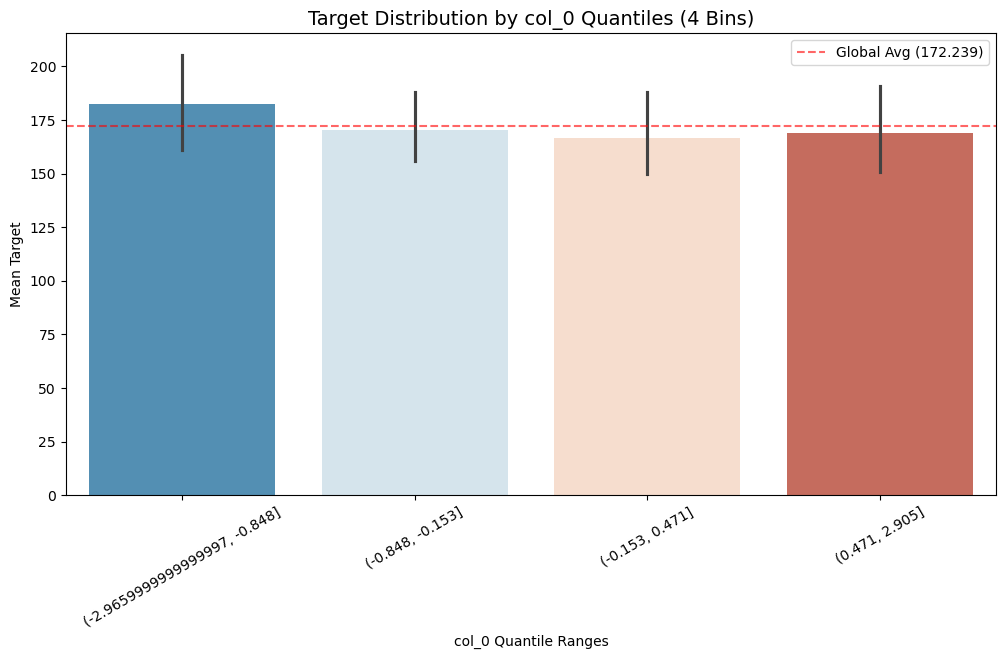

In [10]:
feature_analysis("col_0", 4)

bins with high noise ratios are less trustworthy. Only 15 values in each bin so there is a high risk of overfitting.

no clear features can be made from col_0 as the error bars all overlap too much. Seperating the data into more bins is also not sensible as there is not enough data.

## col_1

,col_1_cut,target
0,"(-2.064, -0.694]",176.368623
1,"(-0.694, 0.063]",177.311623
2,"(0.063, 0.65]",162.262733
3,"(0.65, 2.093]",172.680670


,mean,median,std,count,min,max,noise_ratio
col_1_cut,,,,,,,
"(-2.064, -0.694]",176.368623,164.540754,60.265250,30,98.461197,356.521140,0.341701
"(-0.694, 0.063]",177.311623,165.518292,44.299528,30,107.654181,295.091912,0.249840
"(0.063, 0.65]",162.262733,160.146731,62.400638,29,80.000000,387.079815,0.384565
"(0.65, 2.093]",172.680670,169.172211,52.691644,30,92.379676,400.000000,0.305139


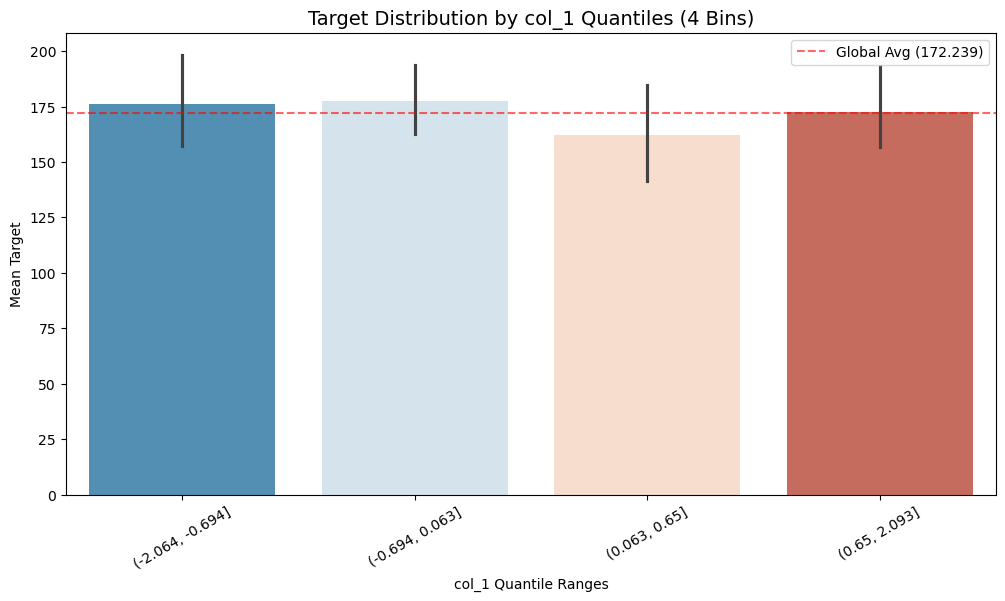

In [11]:
feature_analysis("col_1", 4)

No features can be made from column 1. Error bars are too wide. Col_1 also has very minimal correlation with the target.

In [12]:
best_feat, best_name = find_best_feature_mega(df, 'col_1', 'target')

--- Top 5 Features for col_1 ---
cubed: 0.0203
squared: 0.0177
binned_4: 0.0092
cos_transform: 0.0060
original: 0.0000


C:\Users\kiera\miniconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


col_1 is just noise. 0.02 is not enough to mean something.

## col_2

,col_2_cut,target
0,"(-2.395, -0.501]",173.823001
1,"(-0.501, 0.0906]",166.159833
2,"(0.0906, 0.832]",190.768125
3,"(0.832, 2.517]",158.822869


,mean,median,std,count,min,max,noise_ratio
col_2_cut,,,,,,,
"(-2.395, -0.501]",173.823001,159.050861,63.327225,30,92.379676,356.521140,0.364320
"(-0.501, 0.0906]",166.159833,170.447973,36.257793,30,80.000000,261.402359,0.218210
"(0.0906, 0.832]",190.768125,173.819941,77.053069,29,92.163825,400.000000,0.403910
"(0.832, 2.517]",158.822869,159.677494,25.427379,30,106.576145,201.174902,0.160099


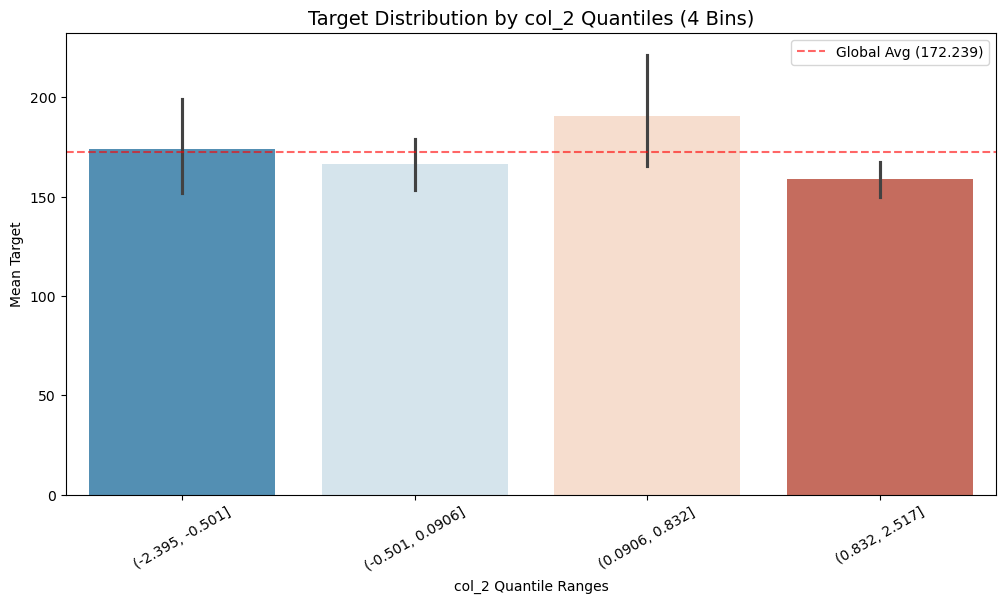

In [13]:
feature_analysis("col_2", 4)

No clear trend and still high overlap amongst columns. It looks like bin 4 may have some predictive power but the correlation between col_2 and the target is minimal. The error bar still overlaps with other bins.

In [14]:
best_feat, best_name = find_best_feature_mega(df, 'col_2', 'target')

--- Top 5 Features for col_2 ---
sin_transform: 0.0841
reciprocal_shifted: 0.0509
sqrt_shifted: 0.0427
yeo_johnson: 0.0419
abs_val: 0.0417


C:\Users\kiera\miniconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


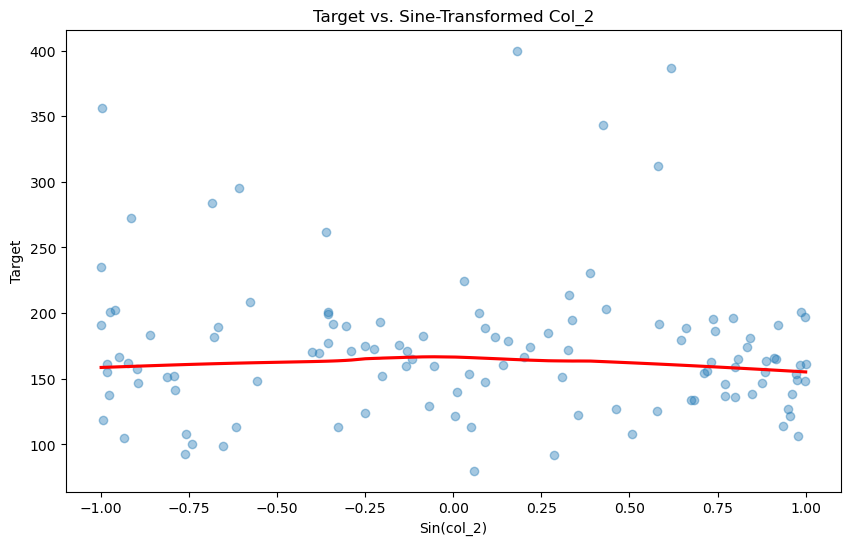

In [15]:
df['col_2_sin'] = np.sin(df['col_2'])

plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='col_2_sin', y='target', 
            lowess=True, 
            line_kws={'color': 'red'},
            scatter_kws={'alpha': 0.4})

plt.title("Target vs. Sine-Transformed Col_2")
plt.xlabel("Sin(col_2)")
plt.ylabel("Target")
plt.show()

sin feature is just noise. no clear trend here.

## col_3

,col_3_cut,target
0,"(-2.932, -0.616]",187.915935
1,"(-0.616, -0.0499]",177.058640
2,"(-0.0499, 0.586]",176.280232
3,"(0.586, 2.914]",147.836092


,mean,median,std,count,min,max,noise_ratio
col_3_cut,,,,,,,
"(-2.932, -0.616]",187.915935,174.105972,68.395722,30,80.000000,400.000000,0.363970
"(-0.616, -0.0499]",177.058640,161.380929,56.648249,30,100.075803,387.079815,0.319941
"(-0.0499, 0.586]",176.280232,171.393473,50.575157,29,107.654181,343.127485,0.286902
"(0.586, 2.914]",147.836092,148.498935,31.733782,30,92.163825,208.078847,0.214655


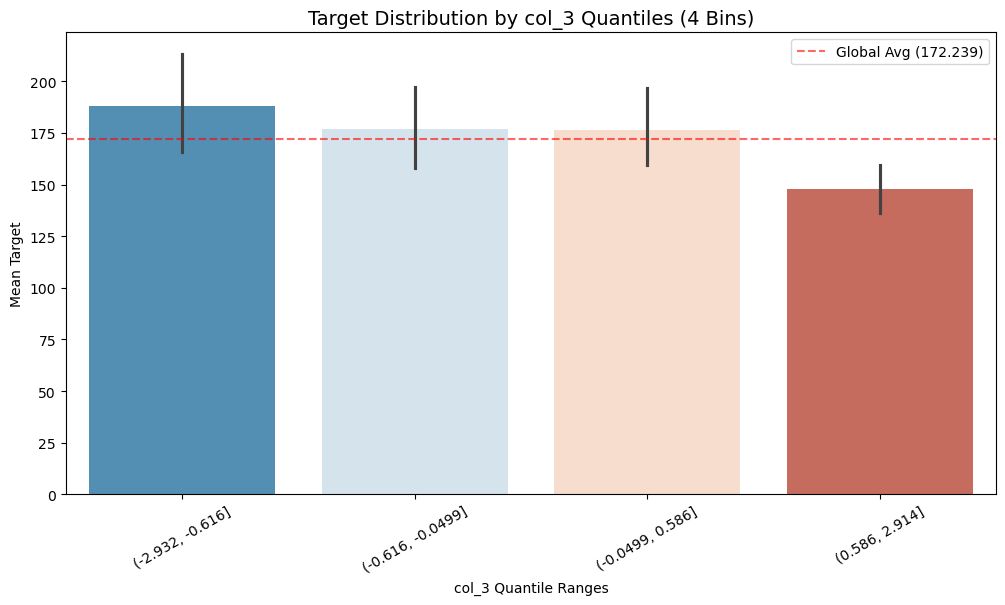

In [16]:
feature_analysis("col_3", 4)

signal in bin 4 of column 3. this can be added as a feature.

In [17]:
df["col_3_extreme"] = np.where(df["col_3"] > 0.586, 1, 0)

In [18]:
correlation = df['col_3_extreme'].corr(df['target'])
print(f"Correlation of new feature: {correlation:.4f}")

Correlation of new feature: -0.2591


correlation of new feature is equal to the correlation of col_3 in the intial correlation heatmap, indicating that this bin is carrying all of the signal for the feature. 

## col_4

,col_4_cut,target
0,"(-2.411, -0.547]",168.720237
1,"(-0.547, 0.0306]",177.972514
2,"(0.0306, 0.688]",165.879546
3,"(0.688, 2.383]",176.171911


,mean,median,std,count,min,max,noise_ratio
col_4_cut,,,,,,,
"(-2.411, -0.547]",168.720237,159.068067,65.917423,30,92.163825,400.000000,0.390691
"(-0.547, 0.0306]",177.972514,170.932329,61.689426,30,80.000000,387.079815,0.346623
"(0.0306, 0.688]",165.879546,161.895062,44.788860,29,107.654181,343.127485,0.270008
"(0.688, 2.383]",176.171911,168.549398,45.645332,30,113.505680,312.225030,0.259095


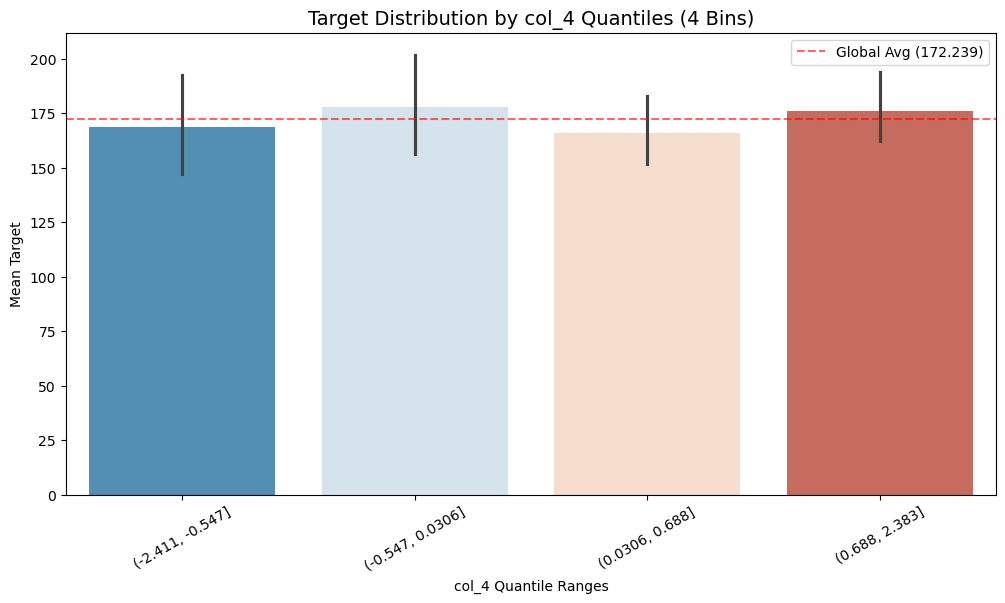

In [19]:
feature_analysis("col_4", 4)

no clear signal

In [20]:
best_feat, best_name = find_best_feature_mega(df, 'col_4', 'target')

--- Top 5 Features for col_4 ---
is_positive: 0.0602
cos_transform: 0.0173
binned_4: 0.0024
original: 0.0000
abs_val: 0.0000


C:\Users\kiera\miniconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


is_positive for column 4 has a stronger correlation (0.06) than the raw feature (0.00), so this may be a potential feature.

In [21]:
def check_binary_split(df, col, target):
    pos = df[df[col] > 0][target]
    neg = df[df[col] <= 0][target]
    
    stats = pd.DataFrame({
        'Count': [len(neg), len(pos)],
        'Mean Target': [neg.mean(), pos.mean()],
        'Std Dev': [neg.std(), pos.std()]
    }, index=['Negative/Zero', 'Positive'])
    
    print("--- Group Statistics ---")
    print(stats)
    
    # Simple T-Test to see if the difference is "real"
    t_stat, p_val = ttest_ind(pos, neg, nan_policy='omit')
    print(f"\nT-test p-value: {p_val:.4f}")
    
    if p_val < 0.05:
        print("Result: Statistically Significant (at 95% confidence)")
    else:
        print("Result: Not Significant (Likely noise)")

check_binary_split(df, 'col_4', 'target')

--- Group Statistics ---
               Count  Mean Target    Std Dev
Negative/Zero     59   172.963317  63.941609
Positive          60   171.526850  44.864971

T-test p-value: 0.8873
Result: Not Significant (Likely noise)


statistically insignificant. col_4 is just noise.

## col_5

,col_5_cut,target
0,"(-3.649, -0.867]",177.307297
1,"(-0.867, -0.0487]",163.302839
2,"(-0.0487, 0.655]",162.649026
3,"(0.655, 2.243]",185.377361


,mean,median,std,count,min,max,noise_ratio
col_5_cut,,,,,,,
"(-3.649, -0.867]",177.307297,160.873231,57.706715,30,104.963261,343.127485,0.325462
"(-0.867, -0.0487]",163.302839,157.049983,52.729155,30,80.000000,387.079815,0.322892
"(-0.0487, 0.655]",162.649026,165.385244,30.534310,29,100.075803,208.078847,0.187731
"(0.655, 2.243]",185.377361,176.243063,69.885436,30,98.461197,400.000000,0.376990


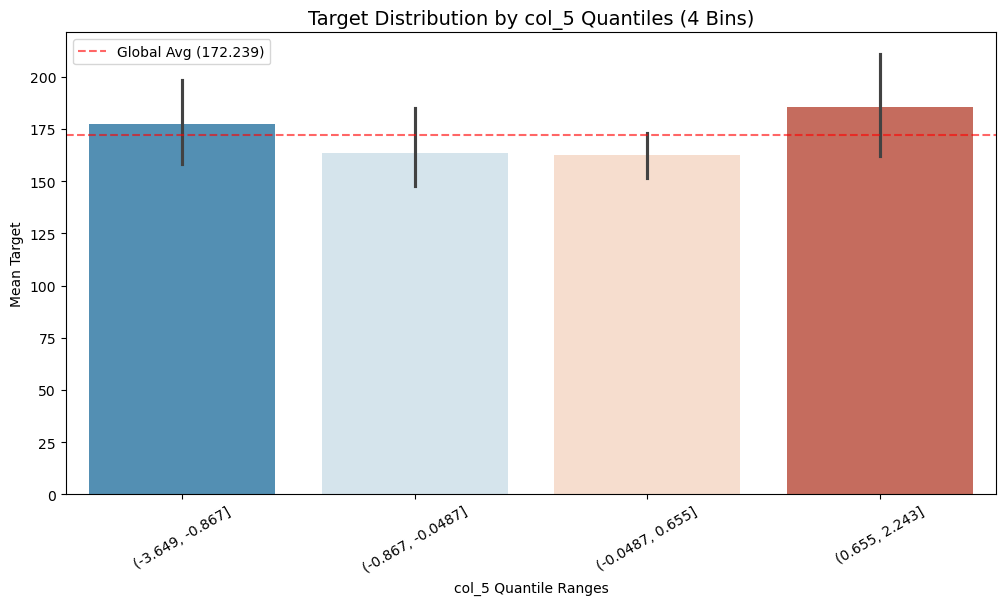

In [22]:
feature_analysis("col_5", 4)

U-shaped graph, implying the relationship may be non-linear / quadratic.

In [23]:
df['col_5_sq'] = df['col_5']**2

# Compare correlations
print(f"Original col_5 Corr: {df['col_5'].corr(df['target']):.4f}")
print(f"Squared col_5 Corr:  {df['col_5_sq'].corr(df['target']):.4f}")

Original col_5 Corr: 0.0311
Squared col_5 Corr:  0.0763


In [24]:
print(f"Absolute col_5 Corr: {df['col_5'].abs().corr(df['target']):.4f}")

Absolute col_5 Corr: 0.0931


In [25]:
# keep absolute value feature
df['abs_col_5'] = abs(df['col_5'])

## col_6

,col_6_cut,target
0,"(-2.685, -0.722]",185.565544
1,"(-0.722, 0.0531]",173.918749
2,"(0.0531, 0.678]",166.854333
3,"(0.678, 2.415]",162.438075


,mean,median,std,count,min,max,noise_ratio
col_6_cut,,,,,,,
"(-2.685, -0.722]",185.565544,171.280234,66.454867,30,80.000000,400.000000,0.358121
"(-0.722, 0.0531]",173.918749,179.068781,44.493093,30,100.075803,312.225030,0.255827
"(0.0531, 0.678]",166.854333,154.799317,55.952750,29,92.163825,387.079815,0.335339
"(0.678, 2.415]",162.438075,164.455958,50.405074,30,92.379676,343.127485,0.310303


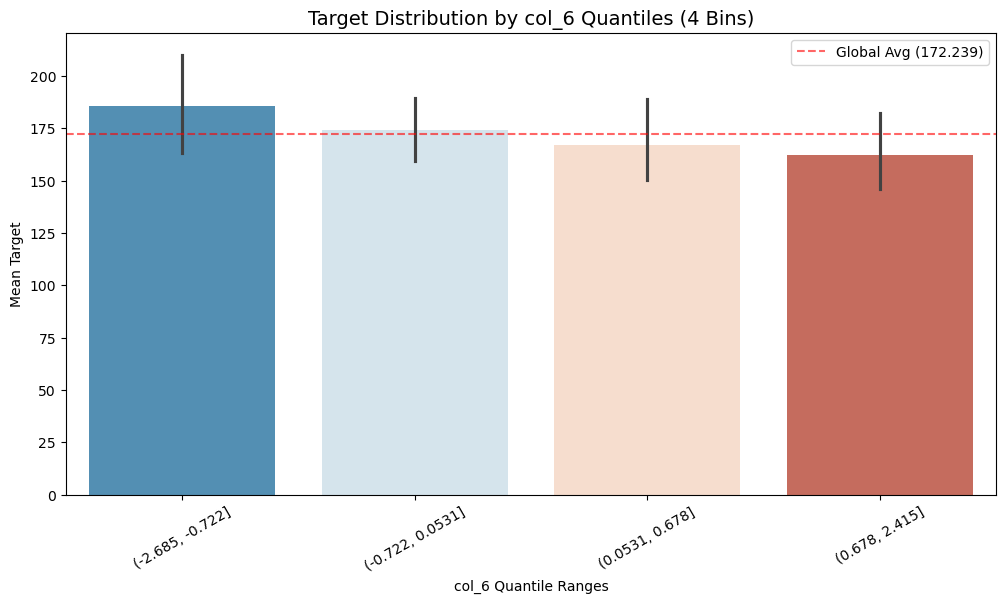

In [26]:
feature_analysis("col_6", 4)

downward trend, but this is just mirroring the singal from col_3 since they are correlated.

In [27]:
best_feat, best_name = find_best_feature_mega(df, 'col_6', 'target')

--- Top 5 Features for col_6 ---
sqrt_shifted: 0.1142
yeo_johnson: 0.1071
original: 0.1036
log_shifted: 0.0973
sin_transform: 0.0919


C:\Users\kiera\miniconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


## col_7

,col_7_cut,target
0,"(-3.07, -0.943]",188.946018
1,"(-0.943, -0.146]",156.163955
2,"(-0.146, 0.697]",167.398114
3,"(0.697, 2.537]",176.286740


,mean,median,std,count,min,max,noise_ratio
col_7_cut,,,,,,,
"(-3.07, -0.943]",188.946018,184.057413,61.051415,30,100.075803,356.521140,0.323116
"(-0.943, -0.146]",156.163955,149.664956,57.591502,30,80.000000,400.000000,0.368789
"(-0.146, 0.697]",167.398114,160.890438,38.831259,29,92.379676,295.091912,0.231970
"(0.697, 2.537]",176.286740,165.998567,56.373200,30,104.963261,387.079815,0.319781


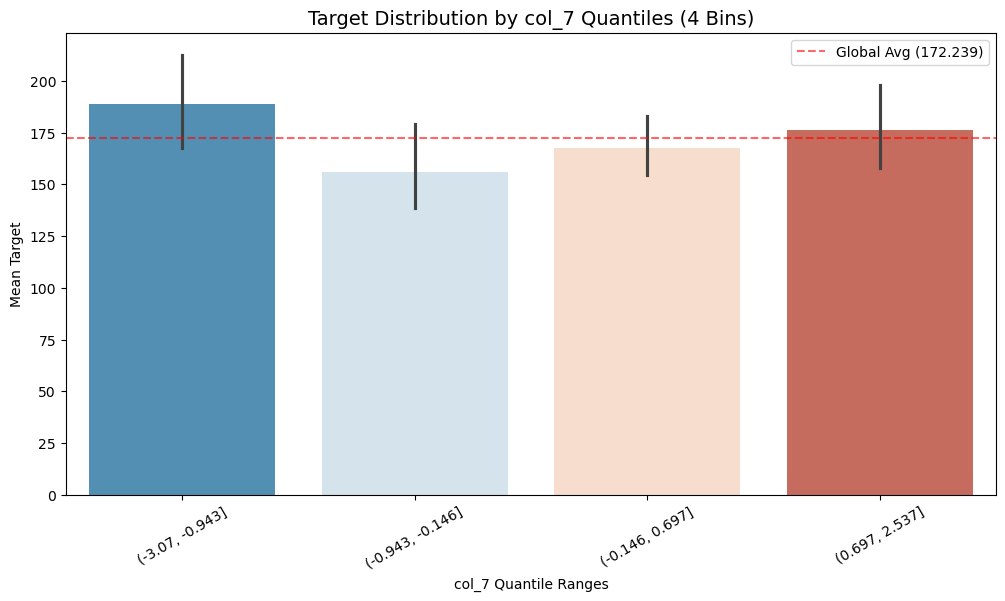

In [28]:
feature_analysis("col_7", 4)

maybe a non-linear relationship

In [29]:
# Check if the absolute value creates a better signal
print(f"Original col_7 Corr: {df['col_7'].corr(df['target']):.4f}")
print(f"Absolute col_7 Corr: {df['col_7'].abs().corr(df['target']):.4f}")

Original col_7 Corr: -0.0930
Absolute col_7 Corr: 0.2074


col_7 has a much stronger relationship with the target when we look at its absolute value!

In [30]:
# keep absolute value feature
df['abs_col_7'] = abs(df['col_7'])

## feature engineering

In [108]:
final_df = pd.read_csv("stock_6_train.csv")

final_df.drop("col_0", axis=1, inplace=True) # multicollinearity with col_7
final_df.drop("col_1", axis=1, inplace=True) # no clear signal
final_df.drop("col_2", axis=1, inplace=True) # no clear signal
# final_df.drop("col_3", axis=1, inplace=True) # ablation test
final_df.drop("col_4", axis=1, inplace=True) # no clear signal
# final_df.drop("col_5", axis=1, inplace=True) # ablation test
final_df.drop("col_6", axis=1, inplace=True) # multicollinearity with col_3
# final_df.drop("col_7", axis=1, inplace=True) # ablation test

final_df["col_3_extreme"] = np.where(df["col_3"] > 0.586, 1, 0)
final_df['abs_col_5'] = abs(df['col_5'])
final_df['abs_col_7'] = abs(df['col_7'])

test_df["col_3_extreme"] = np.where(test_df["col_3"] > 0.586, 1, 0)
test_df['abs_col_5'] = abs(df['col_5'])
test_df['abs_col_7'] = abs(df['col_7'])

### ridge regression

In [65]:
X = final_df.drop(columns=['target', 'target_binary'])
y = final_df['target']

# Split the raw data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipeline = make_pipeline(RobustScaler(), RidgeCV(cv=5))

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)
print(f"R² Score: {r2_score(y_test, preds):.4f}")

weights = pipeline.named_steps['ridgecv'].coef_
ridge_coefs = pd.DataFrame({'Feature': X.columns, 'Weight': weights})
print("\nRidge Feature Weights:")
print(ridge_coefs.sort_values(by='Weight', key=abs, ascending=False))

R² Score: 0.0341

Ridge Feature Weights:
         Feature     Weight
3  col_3_extreme -16.949791
4      abs_col_5  13.941027
5      abs_col_7   6.212483
1          col_5   4.536313
0          col_3  -1.810442
2          col_7   0.109768


In [80]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='r2')
pipeline.fit(X_train, y_train)

best_alpha = pipeline.named_steps['ridgecv'].alpha_
weights = pipeline.named_steps['ridgecv'].coef_

print(f"Individual Fold R²: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Best Alpha chosen: {best_alpha}")

preds = pipeline.predict(X_test)
print(f"Test R² Score: {r2_score(y_test, preds):.4f}")

ridge_coefs = pd.DataFrame({'Feature': X.columns, 'Weight': weights})
print("\nRidge Feature Weights:")
print(ridge_coefs.sort_values(by='Weight', key=abs, ascending=False))

Individual Fold R²: [-0.39424929 -0.0564518   0.00848502 -0.05873401  0.02390237]
Mean CV R²: -0.0954 (+/- 0.1531)
Best Alpha chosen: 10.0
Test R² Score: 0.0341

Ridge Feature Weights:
         Feature     Weight
3  col_3_extreme -16.949791
4      abs_col_5  13.941027
5      abs_col_7   6.212483
1          col_5   4.536313
0          col_3  -1.810442
2          col_7   0.109768


### lasso regression

In [83]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

X = final_df.drop(columns=['target', 'target_binary'])
y = final_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lasso_pipeline = make_pipeline(RobustScaler(), LassoCV(cv=5, random_state=42))

lasso_pipeline.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': lasso_pipeline.named_steps['lassocv'].coef_
}).sort_values(by='Weight', key=abs, ascending=False)

print("\nLasso Feature Weights:")
print(coef_df)


Lasso Feature Weights:
         Feature     Weight
3  col_3_extreme -14.080328
4      abs_col_5  10.596820
5      abs_col_7   2.223358
0          col_3  -0.000000
1          col_5   0.000000
2          col_7  -0.000000


#### lasso cv

In [84]:
lasso_pipeline = make_pipeline(RobustScaler(), LassoCV(cv=5, random_state=42))
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(lasso_pipeline, X_train, y_train, cv=kf, scoring='r2')

lasso_pipeline.fit(X_train, y_train)

best_alpha_lasso = lasso_pipeline.named_steps['lassocv'].alpha_
weights_lasso = lasso_pipeline.named_steps['lassocv'].coef_

print(f"--- Lasso Cross-Validation (K-Fold) ---")
print(f"Individual Fold R²: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Best Alpha chosen: {best_alpha_lasso:.6f}")

lasso_preds = lasso_pipeline.predict(X_test)
print(f"\nFinal Test R² Score: {r2_score(y_test, lasso_preds):.4f}")

--- Lasso Cross-Validation (K-Fold) ---
Individual Fold R²: [-0.54685204 -0.15350153  0.08934295 -0.01597692  0.01348622]
Mean CV R²: -0.1227 (+/- 0.2262)
Best Alpha chosen: 3.060909

Final Test R² Score: -0.0012


### Huber regressor (robust to outliers)

In [85]:
huber_pipeline = make_pipeline(RobustScaler(), HuberRegressor())

cv_scores = cross_val_score(huber_pipeline, X, final_df['target'], cv=5)

print(f"Huber Mean CV R²: {cv_scores.mean():.4f}")

Huber Mean CV R²: -0.1097


## Binary classification - higher or lower than the mean?

In [91]:
X_class = final_df.drop(columns=['target', 'target_binary'])
y_continuous = final_df['target']

X_train, X_test, y_train_cont, y_test_cont = train_test_split(
    X_class, y_continuous, test_size=0.3, random_state=42
)

train_median = y_train_cont.median()
y_train_bin = (y_train_cont > train_median).astype(int)
y_test_bin = (y_test_cont > train_median).astype(int) 

clf_pipeline = make_pipeline(RobustScaler(), LogisticRegressionCV(cv=5, penalty='l2', random_state=42))

cv_acc = cross_val_score(clf_pipeline, X_train, y_train_bin, cv=5)

clf_pipeline.fit(X_train, y_train_bin)
test_accuracy = clf_pipeline.score(X_test, y_test_bin)

print(f"Mean CV Accuracy: {cv_acc.mean():.4f}")
print(f"Fold Accuracies: {cv_acc}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Mean CV Accuracy: 0.4824
Fold Accuracies: [0.52941176 0.41176471 0.47058824 0.5        0.5       ]
Final Test Accuracy: 0.3611


In [101]:
y_true = final_df['target_binary'].values
y_pred_loo = []

for train_index, test_index in loo.split(X_class):
    X_train_loo, X_test_loo = X_class.iloc[train_index], X_class.iloc[test_index]
    y_train_loo = y_true[train_index]
    
    clf_pipeline.fit(X_train_loo, y_train_loo)
    y_pred_loo.append(clf_pipeline.predict(X_test_loo)[0])

y_pred_loo = np.array(y_pred_loo)
actual_acc = accuracy_score(y_true, y_pred_loo)
flipped_acc = accuracy_score(y_true, 1 - y_pred_loo)

print(f"LOOCV Actual Accuracy: {actual_acc:.4f}")
print(f"LOOCV Flipped Accuracy: {flipped_acc:.4f}")

LOOCV Actual Accuracy: 0.2773
LOOCV Flipped Accuracy: 0.7227


### knn

In [39]:
final_df

,col_3,col_5,col_7,target,col_3_extreme,abs_col_5,abs_col_7,target_binary
0,0.232878,0.270343,-0.760052,146.787077,0,0.270343,0.760052,0
1,-0.457699,1.309551,-0.375889,196.708960,0,1.309551,0.375889,1
2,1.128972,-0.840156,-0.798076,125.201647,1,0.840156,0.798076,0
3,1.320662,-1.476858,-0.146051,122.023737,1,1.476858,0.146051,0
4,-1.326393,-0.484169,-1.434372,195.946833,0,0.484169,1.434372,1
...,...,...,...,...,...,...,...,...
114,-0.489750,0.031086,-0.451510,177.044909,0,0.031086,0.451510,1
115,-0.529493,0.021852,0.264255,199.701818,0,0.021852,0.264255,1
116,-2.247269,1.187725,0.079271,235.489057,0,1.187725,0.079271,1
117,-2.333616,0.749434,-2.473157,356.521140,0,0.749434,2.473157,1


In [40]:
X = final_df.drop(columns=['target', 'target_binary'])
y = final_df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

param_grid = {'n_neighbors': range(3, 25)}
knn_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='r2')
knn_search.fit(X_scaled, y)

print(f"Best K Neighbors: {knn_search.best_params_['n_neighbors']}")
print(f"Best Training R²: {knn_search.best_score_:.4f}")

best_knn = knn_search.best_estimator_
cv_scores = cross_val_score(best_knn, X_scaled, y, cv=5)

print(f"Average CV R²: {cv_scores.mean():.4f}")
print(f"Fold Scores: {cv_scores}")

Best K Neighbors: 23
Best Training R²: -0.0634
Average CV R²: -0.0634
Fold Scores: [-0.06340617 -0.31955256  0.06762294  0.06862728 -0.07039186]


no signal in knn, just overfitting

### svr

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_df.drop(columns=["target", "target_binary"]))
y = final_df['target']

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'epsilon': [0.1, 0.2, 0.5]
}

grid_svr = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2')
grid_svr.fit(X_scaled, y)

print(f"Best Params: {grid_svr.best_params_}")
print(f"Best CV R²: {grid_svr.best_score_:.4f}")

best_svr = grid_svr.best_estimator_
cv_scores = cross_val_score(best_svr, X_scaled, y, cv=5)

print(f"Fold Scores: {cv_scores}")

Best Params: {'C': 1, 'epsilon': 0.5, 'gamma': 0.01}
Best CV R²: -0.0447
Fold Scores: [-0.08383746 -0.01867704  0.00497103  0.00056349 -0.12669251]


negative r squared score

# Test data

In [104]:
test_df = pd.read_csv("stock_6_test.csv")

In [105]:
test_df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7
0,-0.812941,-0.415357,-0.612097,-0.140791,1.06598,0.157049,0.169878,0.056431


In [114]:
clf_pipeline.fit(X_class, y_true)

X_single_test = test_df[X_class.columns] 

single_prediction = clf_pipeline.predict(X_single_test)[0]

single_proba = clf_pipeline.predict_proba(X_single_test)[0]

print(f"Predicted Class: {single_prediction}")
print(f"Confidence Scores: {clf_pipeline.classes_} -> {single_proba}")

Predicted Class: 0
Confidence Scores: [0 1] -> [0.50414797 0.49585203]


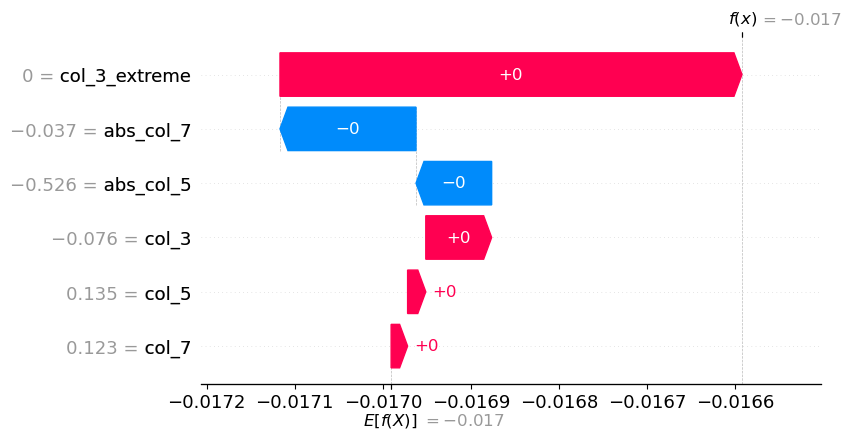

In [115]:
scaler = clf_pipeline.named_steps['robustscaler']
model = clf_pipeline.named_steps['logisticregressioncv']

X_train_scaled = scaler.transform(X_class)
X_test_scaled = scaler.transform(X_single_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=X_class.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_class.columns)

explainer = shap.Explainer(model, X_train_df)
shap_values = explainer(X_test_df)

shap.plots.waterfall(shap_values[0])

it is not clear if the predicted value is going to be above the mean of the data (1) or below the mean (0). 

In [117]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# 1. Define individual strong learners
# Logistic Regression (Linear)
lr = LogisticRegressionCV(cv=5, max_iter=1000)

# Random Forest (Non-linear/Interaction based)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Support Vector Machine (Spatial/Boundary based)
# Note: probability=True is required for soft voting
svc = SVC(probability=True, kernel='rbf')

# 2. Create the Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('svc', svc)
    ],
    voting='soft', # Averages the probabilities
    weights=[1, 2, 1] # You can give more weight to the model that performed best in LOOCV
)

# 3. Wrap in a pipeline with your scaler
ensemble_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', ensemble)
])

# 4. Train on your full X_class, y_true
ensemble_pipeline.fit(X_class, y_true)

# 5. Predict your single test row
final_proba = ensemble_pipeline.predict_proba(X_single_test)
final_pred = ensemble_pipeline.predict(X_single_test)

print(f"Ensemble Probability: {final_proba[0]}")
print(f"Final Decision: {final_pred[0]}")

Ensemble Probability: [0.63103699 0.36896301]
Final Decision: 0


In [119]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
import numpy as np

loo = LeaveOneOut()
y_true = final_df['target_binary'].values
y_pred_ensemble = []

print("Starting LOOCV for Ensemble... (This may take a moment)")

for train_index, test_index in loo.split(X_class):
    # Split data
    X_train_loo, X_test_loo = X_class.iloc[train_index], X_class.iloc[test_index]
    y_train_loo = y_true[train_index]
    
    # Fit the entire pipeline (Scaler + Ensemble) on N-1 rows
    ensemble_pipeline.fit(X_train_loo, y_train_loo)
    
    # Predict the held-out row
    y_pred_ensemble.append(ensemble_pipeline.predict(X_test_loo)[0])

# Calculate Accuracy
ensemble_acc = accuracy_score(y_true, y_pred_ensemble)
print(f"--- Results ---")
print(f"Ensemble LOOCV Accuracy: {ensemble_acc:.4f}")

KeyError: 'target_binary'

In [120]:
print(final_df.columns.tolist())

['col_3', 'col_5', 'col_7', 'target', 'col_3_extreme', 'abs_col_5', 'abs_col_7']
